In [1]:
import torch
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import json

In [2]:
# Download MNIST dataset
transform = transforms.ToTensor()
data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

In [3]:
# Extract data to a tensor and normalize pixel values [0.0 - 1.0]
X_data = data.data.float()/255.0
Y_data = data.targets

print("X_data shape:", X_data.shape)
print("Y_data shape:", Y_data.shape)

X_data shape: torch.Size([60000, 28, 28])
Y_data shape: torch.Size([60000])


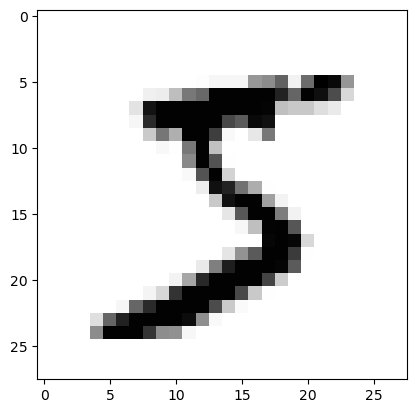

In [4]:
plt.imshow(X_data[0], cmap= 'Greys')

In [5]:
# Separate the data into train/validation/test
train_index = int(X_data.shape[0] * 0.8)
test_index = int(X_data.shape[0] * 0.9)

X_train = X_data[:train_index]
Y_train = Y_data[:train_index]

X_val = X_data[train_index:test_index]
Y_val = Y_data[train_index:test_index]

X_test = X_data[test_index:]
Y_test = Y_data[test_index:]

print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Test shape: {X_test.shape}")

Training shape: torch.Size([48000, 28, 28])
Validation shape: torch.Size([6000, 28, 28])
Test shape: torch.Size([6000, 28, 28])


In [6]:
# ── Parameters ────────────────────────────────────────────────────────────

N_HIDDEN    = 128
BATCH_SIZE  = 64
EPOCHS      = 10
LR_INITIAL  = 0.1
LR_FINAL    = 0.01  # Step decay at the last epochs

# ── Weight initialization ──────────────────────────────────────────────────────

def init_parameters(n_in: int, n_hidden: int, n_out: int) -> list[torch.Tensor]:
    """Using Kaiming initialization."""
    W1 = torch.randn(n_in, n_hidden) * (1.0 / n_in ** 0.5)
    b1 = torch.zeros(n_hidden)
    W2 = torch.randn(n_hidden, n_out) * (1.0 / n_hidden ** 0.5)
    b2 = torch.zeros(n_out)
    return [W1, b1, W2, b2]

# ── Forward pass ───────────────────────────────────────────────────────────────

def forward(X: torch.Tensor, W1, b1, W2, b2):
    """
    Returns a dict of all intermediate values needed by the backward pass.
    """
    # Layer 1: linear + ReLU
    l1 = X @ W1 + b1
    a1 = l1.clamp(min=0.0)

    # Layer 2: linear → softmax → log-probabilities
    logits     = a1 @ W2 + b2                     
    safe_logits = logits - logits.max(1, keepdim=True).values # Substract maxes for numerical stability
    counts     = safe_logits.exp()
    counts_sum = counts.sum(1, keepdim=True)
    probs      = counts / counts_sum                          # Softmax
    logprobs   = probs.log()

    return dict(l1=l1, a1=a1, logits=logits,
                counts=counts, counts_sum=counts_sum, probs=probs, logprobs=logprobs)

def nll_loss(logprobs: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    """Negative log-likelihood averaged over the batch."""
    B = targets.shape[0]
    return -logprobs[range(B), targets].mean()

# ── Backward pass ──────────────────────────────────────────────────────────────

def backward(cache: dict, targets: torch.Tensor,
             X: torch.Tensor, W2: torch.Tensor) -> list[torch.Tensor]:
    """
    Manually derived gradients. Returns [dW1, db1, dW2, db2].
    """
    B = targets.shape[0]
    l1, a1     = cache['l1'], cache['a1']
    logits     = cache['logits']
    counts     = cache['counts']
    counts_sum = cache['counts_sum']
    probs      = cache['probs']

    # ∂L/∂logprobs
    dlogprobs = torch.zeros_like(probs)
    dlogprobs[range(B), targets] = -1.0 / B

    # ∂L/∂probs
    dprobs = (1.0 / probs) * dlogprobs

    # ∂L/∂counts and ∂L/∂counts_sum
    counts_sum_inv  = counts_sum ** -1
    dcounts_sum_inv = (counts * dprobs).sum(1, keepdim=True)   # Because of broadcasting
    dcounts         = counts_sum_inv * dprobs
    dcounts_sum     = (-counts_sum ** -2) * dcounts_sum_inv
    dcounts        += torch.ones_like(counts) * dcounts_sum

    # ∂L/∂logits  (max subtraction doesn't affect gradients)
    dsafe_logits = counts * dcounts
    dlogits      = dsafe_logits.clone()
    dmax_logits  = (-dsafe_logits).sum(1, keepdim=True)        # Because of broadcasting
    dlogits     += F.one_hot(logits.max(1).indices, num_classes=logits.shape[1]) * dmax_logits

    # ∂L/∂W2, ∂L/∂b2
    dW2 = a1.T @ dlogits
    db2 = dlogits.sum(0)

    # ∂L/∂a1 → ∂L/∂l1 (ReLU)
    da1 = dlogits @ W2.T
    dl1 = (l1 > 0).float() * da1

    # ∂L/∂W1, ∂L/∂b1
    dW1 = X.T @ dl1
    db1 = dl1.sum(0)

    return [dW1, db1, dW2, db2]

# ── SGD update ────────────────────────────────────────────────────────────────

def sgd_step(parameters: list, grads: list, lr: float) -> None:
    """Parameters update."""
    for p, grad in zip(parameters, grads):
        p += -lr * grad

# ── Validation ────────────────────────────────────────────────────────────────

@torch.no_grad()
def evaluate(X_val: torch.Tensor, Y_val: torch.Tensor,
             W1, b1, W2, b2) -> float:
    """Returns accuracy on the validation set."""
    cache = forward(X_val.view(-1, 784), W1, b1, W2, b2)
    predictions = cache['logits'].argmax(dim=1)
    return (predictions == Y_val).float().mean().item()

In [7]:
    # ── Training loop ─────────────────────────────────────────────────────────────

W1, b1, W2, b2 = init_parameters(n_in=784, n_hidden=N_HIDDEN, n_out=10)
parameters = [W1, b1, W2, b2]
loss_history: list[float] = []

print("Starting training...")
print(f"  Architecture : 784 → {N_HIDDEN} (ReLU) → 10 (softmax)")
print(f"  Batch size   : {BATCH_SIZE}  |  Epochs: {EPOCHS}")
print()

for epoch in range(EPOCHS):
    # Step decay: lower lr at the final epochs
    lr = LR_FINAL if epoch == EPOCHS - 1 else LR_INITIAL
    print(f"── Epoch {epoch + 1}/{EPOCHS}  (lr={lr}) " + "─" * 30)

    for step, i in enumerate(range(0, len(X_train), BATCH_SIZE)):
        # ── Mini-batch ────────────────────────────────────────────
        X_batch = X_train[i : i + BATCH_SIZE].view(-1, 784)
        Y_batch = Y_train[i : i + BATCH_SIZE]

        # ── Forward ───────────────────────────────────────────────
        cache = forward(X_batch, W1, b1, W2, b2)
        loss  = nll_loss(cache['logprobs'], Y_batch)

        # ── Backward ──────────────────────────────────────────────
        grads = backward(cache, Y_batch, X_batch, W2)

        # ── Update ────────────────────────────────────────────────
        sgd_step(parameters, grads, lr)

        loss_history.append(loss.log10().item())

        if step % 200 == 0:
            print(f"  step {step:4d} | loss {loss.item():.4f}")

    # ── Validation ────────────────────────────────────────────────
    acc = evaluate(X_val, Y_val, W1, b1, W2, b2)
    print(f"  → Validation accuracy: {acc * 100:.2f}%\n")

Starting training...
  Architecture : 784 → 128 (ReLU) → 10 (softmax)
  Batch size   : 64  |  Epochs: 10

── Epoch 1/10  (lr=0.1) ──────────────────────────────
  step    0 | loss 2.3276
  step  200 | loss 0.3388
  step  400 | loss 0.2388
  step  600 | loss 0.2116
  → Validation accuracy: 91.52%

── Epoch 2/10  (lr=0.1) ──────────────────────────────
  step    0 | loss 0.2288
  step  200 | loss 0.1643
  step  400 | loss 0.1414
  step  600 | loss 0.1244
  → Validation accuracy: 93.52%

── Epoch 3/10  (lr=0.1) ──────────────────────────────
  step    0 | loss 0.1373
  step  200 | loss 0.1305
  step  400 | loss 0.1002
  step  600 | loss 0.0874
  → Validation accuracy: 94.57%

── Epoch 4/10  (lr=0.1) ──────────────────────────────
  step    0 | loss 0.0999
  step  200 | loss 0.1094
  step  400 | loss 0.0828
  step  600 | loss 0.0690
  → Validation accuracy: 95.23%

── Epoch 5/10  (lr=0.1) ──────────────────────────────
  step    0 | loss 0.0798
  step  200 | loss 0.0928
  step  400 | loss 

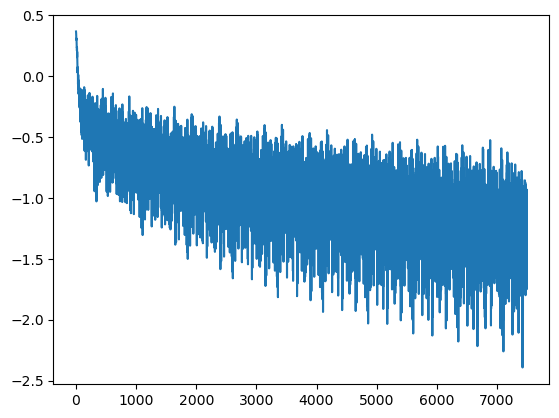

In [8]:
# Visualize loss over time
plt.plot(loss_history)

In [9]:
# Test the model
test = evaluate(X_test, Y_test, W1, b1, W2, b2)
print(f" Test accuracy: {test * 100: .2f}%")

 Test accuracy:  97.97%


In [10]:
# Confusion Matrix Visualization
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

def conf_mat(X_val: torch.Tensor, Y_val: torch.Tensor, W1, b1, W2, b2):

    cache = forward(X_val.view(-1, 784), W1, b1, W2, b2)
    predictions = cache['logits'].argmax(dim=1)

    cm = np.zeros((10, 10), dtype=np.int32)

    for true, pred in zip(Y_val.cpu().numpy(), predictions.cpu().numpy()):
        cm[true, pred] += 1

    return cm


def plot_confusion_matrix(cm, normalize=True):
    cm = cm.astype(float)

    # Normalize
    if normalize:
        cm = cm / cm.sum(axis=1, keepdims=True)

    fig, ax = plt.subplots(figsize=(7, 6))

    im = ax.imshow(cm, cmap="viridis")

    # Labels
    classes = [str(i) for i in range(10)]
    ax.set_xticks(np.arange(10))
    ax.set_yticks(np.arange(10))
    ax.set_xticklabels(classes)
    ax.set_yticklabels(classes)

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title("Confusion Matrix (Normalized)" if normalize else "Confusion Matrix")

    # Annotate cells (only meaningful values)
    threshold = 0.01 if normalize else 1

    for i in range(10):
        for j in range(10):
            value = cm[i, j]
            if value > threshold:
                text = f"{value:.2f}" if normalize else str(int(value))
                ax.text(j, i, text, ha="center", va="center", fontsize=9, color="white")

    # Clean style
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks(np.arange(-.5, 10, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 10, 1), minor=True)
    ax.grid(which="minor", color="white", linestyle='-', linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Proportion" if normalize else "Count")

    plt.tight_layout()

    plt.show()

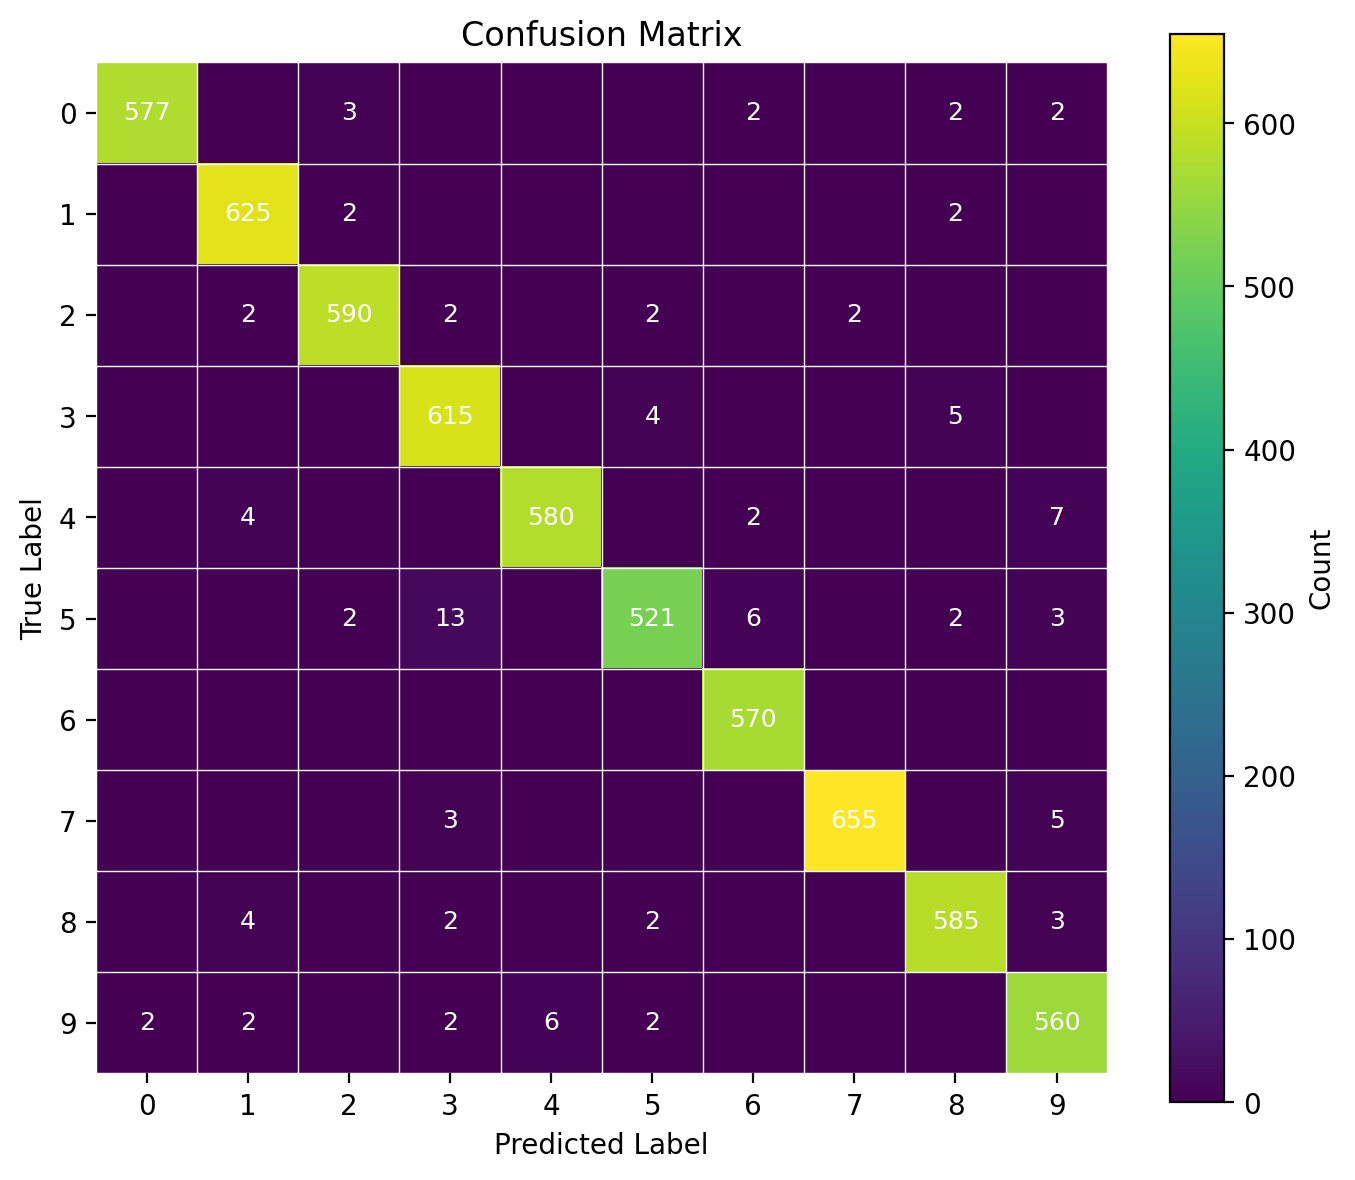

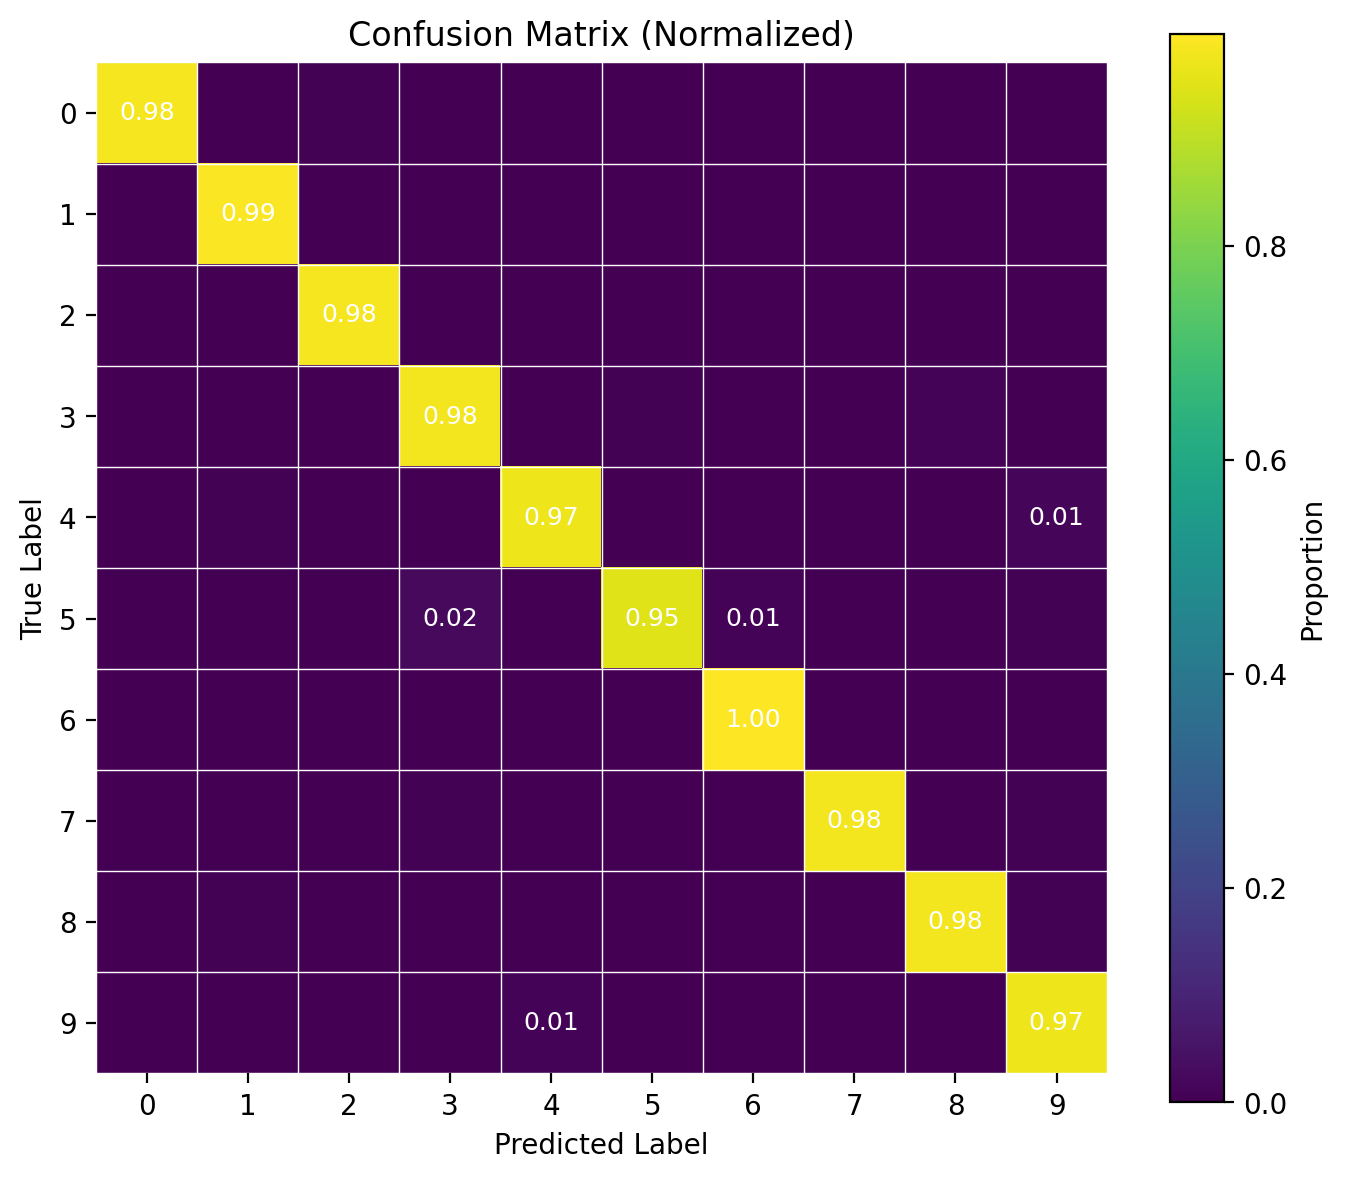

In [11]:
cm = conf_mat(X_test, Y_test, W1, b1, W2, b2)
plot_confusion_matrix(cm, normalize=False)
plot_confusion_matrix(cm, normalize=True)

In [12]:
# Error Visualization
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
def plot_errors(X_val: torch.Tensor, Y_val: torch.Tensor, W1, b1, W2, b2, num_images = 15):
    cache = forward(X_val.view(-1, 784), W1, b1, W2, b2)
    
    # Obtain predictions and create a mask
    predictions = cache["logits"].argmax(dim=1)
    errors_mask = predictions != Y_val

    error_indices = errors_mask.nonzero(as_tuple=True)[0] #Gives us the indices of the errors

    num_errors = len(error_indices)
    if num_errors > 0:
        num_to_plot = min(num_images, num_errors)
        print(f"Displaying {num_to_plot} out of {num_errors} misclassified images.")
        cols = 4
        rows = (num_to_plot + cols - 1) // cols
        fig, axes = plt.subplots(rows, cols, figsize=(12, 2.5 * rows))
        axes = axes.flatten()

        for i in range(num_to_plot):
            idx = error_indices[i].item()
        
            img = X_val[idx].cpu().numpy().reshape(28, 28)
        
            true_label = Y_val[idx].item()
            pred_label = predictions[idx].item()
        
            axes[i].imshow(img, cmap='Greys')
            axes[i].set_title(f"True: {true_label} | Pred: {pred_label}")
            axes[i].axis('off')
        
            # Hide any unused subplots if num_to_plot doesn't perfectly fill the grid
        for j in range(num_to_plot, len(axes)):
            axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()    

Displaying 15 out of 122 misclassified images.


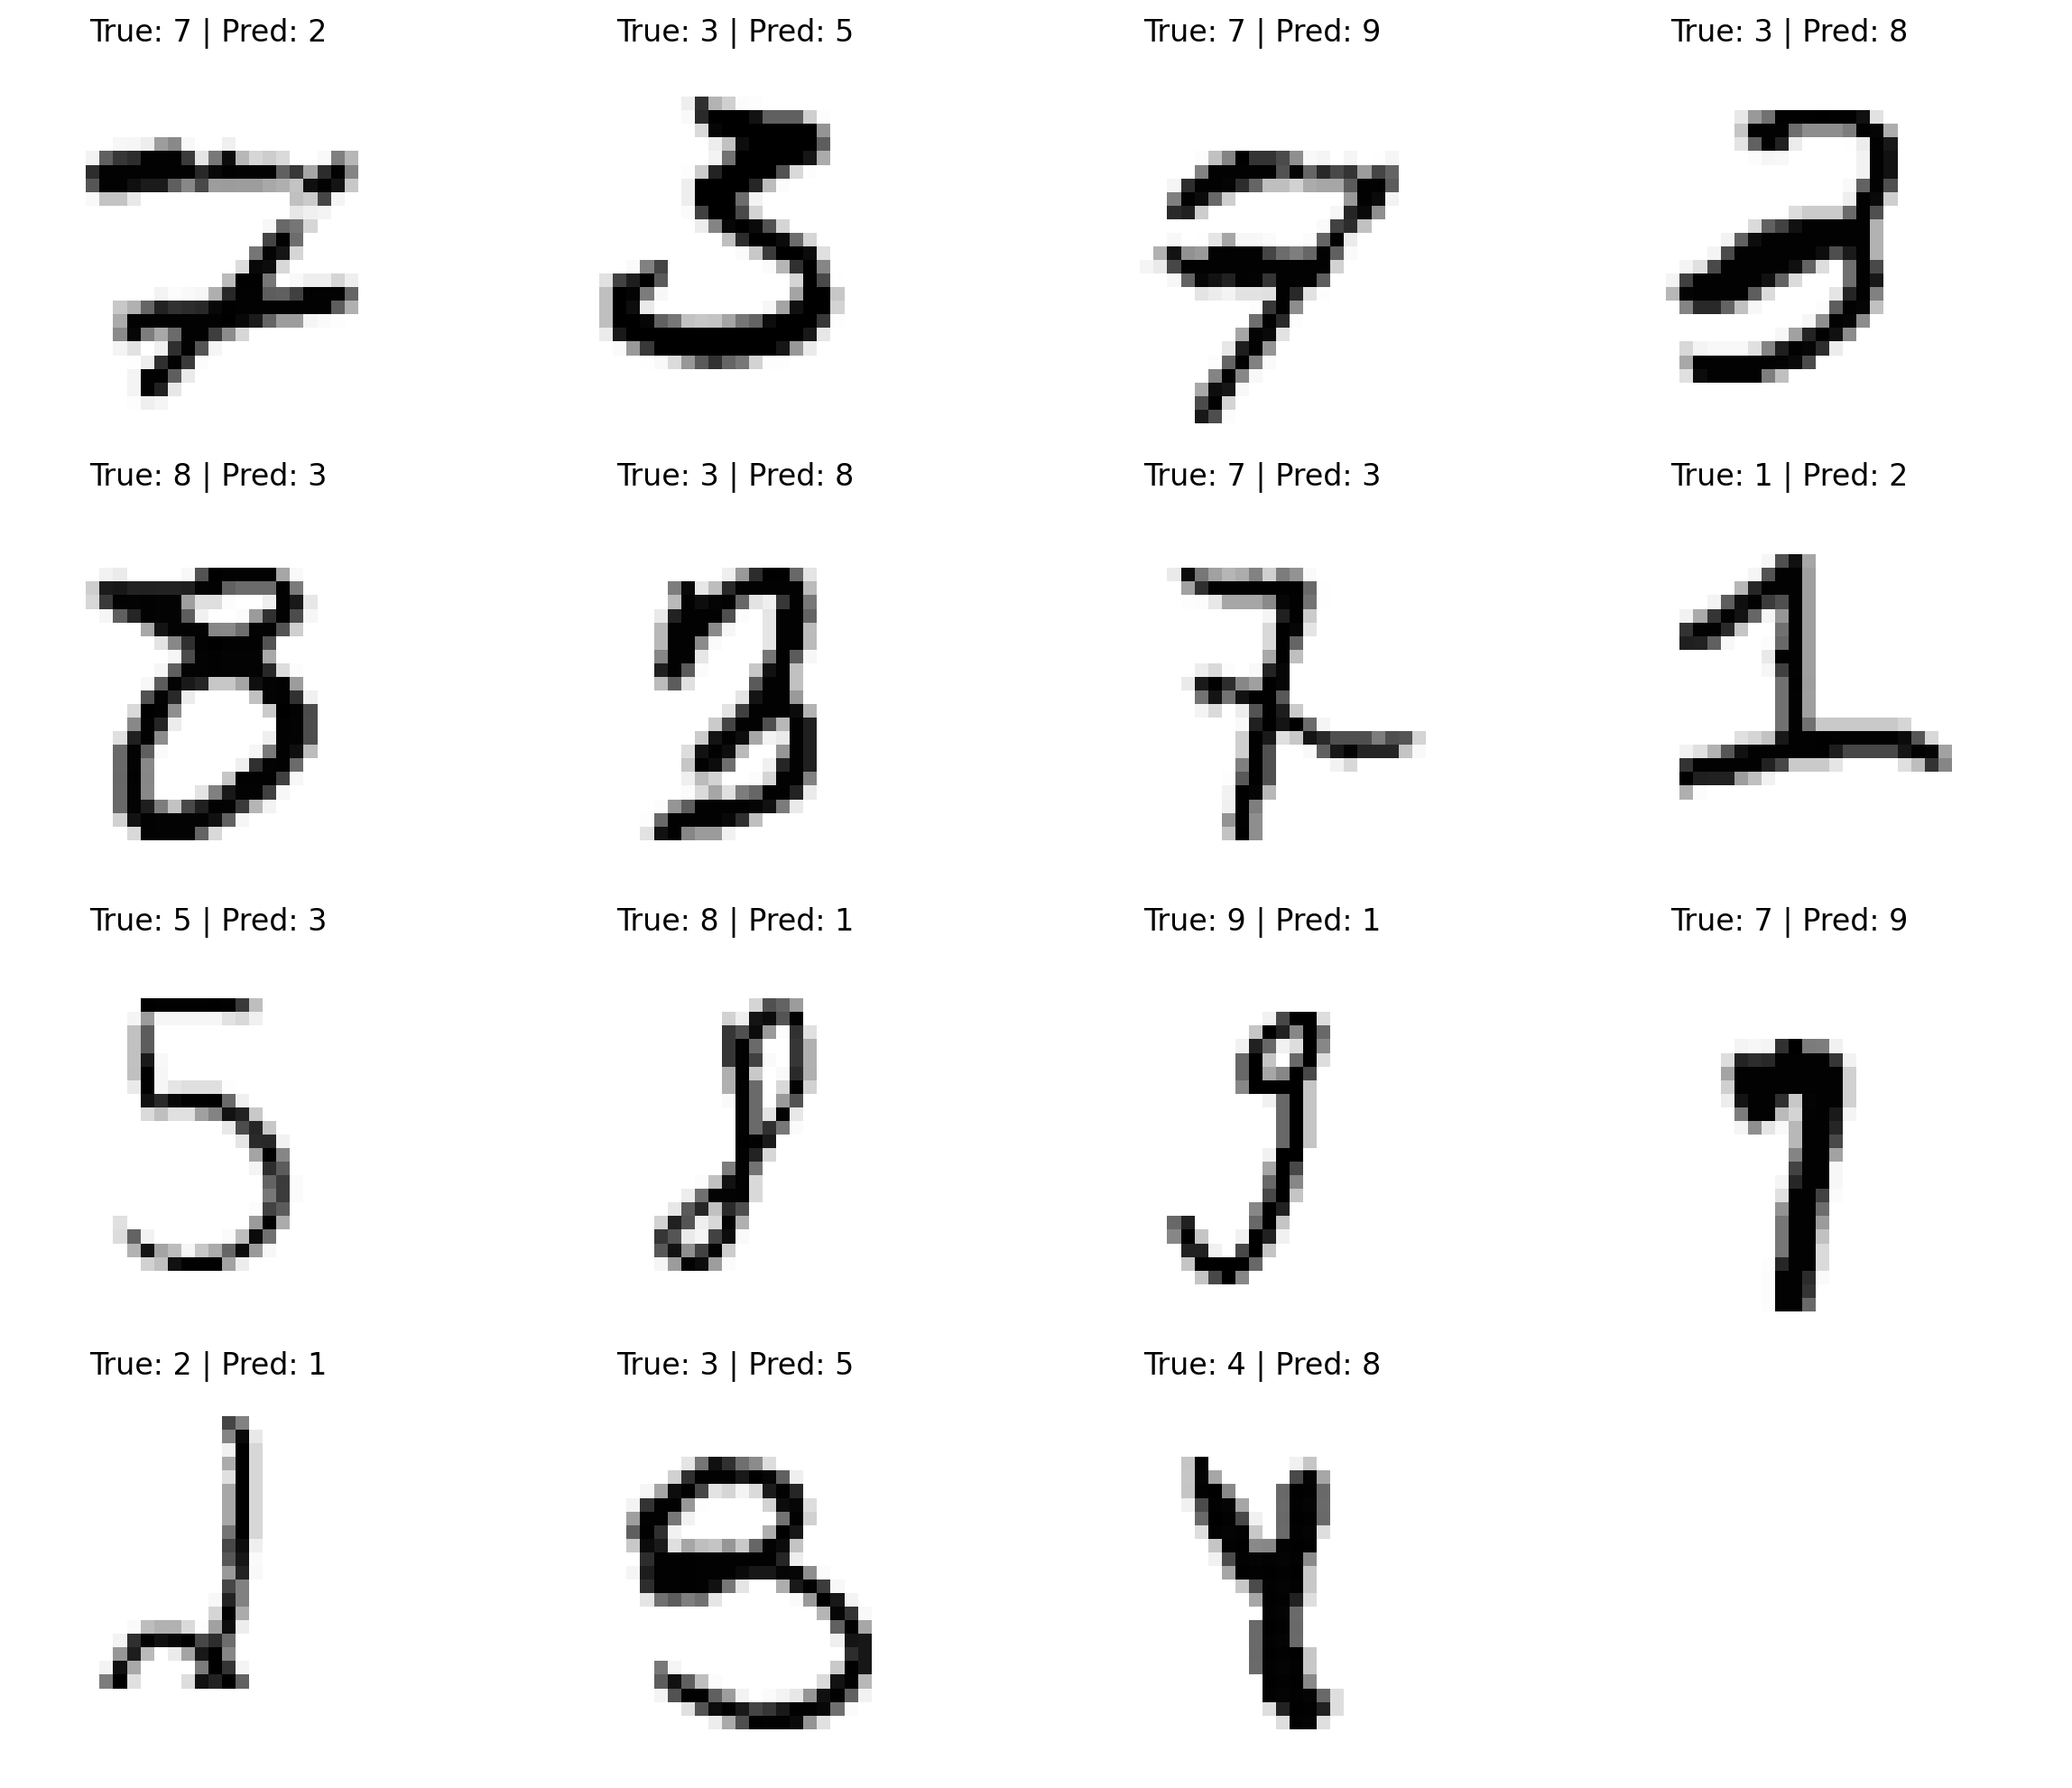

In [13]:
plot_errors(X_test, Y_test, W1, b1, W2, b2)

In [19]:
# Export weights and biases for web implementation
model_data = {
    "w1": W1.detach().cpu().flatten().tolist(),
    "b1": b1.detach().cpu().flatten().tolist(),
    "w2": W2.detach().cpu().flatten().tolist(),
    "b2": b2.detach().cpu().flatten().tolist(),
    "hidden_size": W1.shape[1]  
}

with open("weights.json", "w") as f:
    json.dump(model_data, f)

print("Exported PyTorch weights successfully!")

Exported PyTorch weights successfully!
